# Do Dado ao Produto — Ciência de Dados Aplicada
## Projeto Final de Machine Learning
### Miqueias Teixeira

---

## 1. Introdução

Neste trabalho, o objetivo é construir um modelo de Machine Learning capaz de prever o valor total de uma compra em um supermercado a partir das características dos produtos adquiridos.

A ideia é responder à seguinte pergunta:

> **"Será que é possível estimar quanto uma pessoa vai gastar apenas analisando algumas informações da compra?"**

Para isso, o conjunto de dados fornece variáveis como:

- Quantidade de itens comprados;
- Categoria do produto;
- Preço unitário;
- Dia da semana em que a compra foi realizada;
- Avaliação (*rating*) da compra, entre outras.

A partir dessas informações, o modelo deve prever o **valor total da compra**.

Como a variável que desejamos prever é um valor numérico contínuo, este problema é classificado como um problema de **regressão**. Diferentemente da classificação, em que o objetivo é prever categorias, na regressão buscamos estimar um valor numérico com base nas variáveis disponíveis.

Esse tipo de abordagem possui diversas aplicações práticas. Em um supermercado, por exemplo, um modelo desse tipo pode auxiliar na estimativa de faturamento, no planejamento de estoque e até mesmo na tomada de decisões relacionadas à gestão de vendas.

Nas etapas seguintes, será apresentado todo o processo de desenvolvimento do modelo, desde a análise exploratória e preparação dos dados até o treinamento, avaliação e interpretação dos resultados obtidos.

## 2. Sobre os dados

Para este trabalho foi utilizado o conjunto de dados **"Supermarket Sales"**, disponibilizado na plataforma Kaggle.

**Dataset:** https://www.kaggle.com/datasets/markmedhat/supermarket-sales

### Preparação

Para executar este notebook, basta seguir os passos abaixo:

1. Fazer o download do arquivo `supermarket_sales.csv` no Kaggle;
2. Criar uma pasta chamada `dados` no mesmo diretório deste notebook;
3. Colocar o arquivo dentro dessa pasta, ficando com a seguinte estrutura:

```text
projeto/
│
├── notebook.ipynb
├── app.py
└── dados/
    └── supermarket_sales.csv
```

### Descrição das variáveis

O dataset contém informações sobre vendas realizadas em um supermercado, incluindo características dos clientes, produtos e da compra. As principais colunas utilizadas são:

| Coluna | Descrição |
|---------|-----------|
| **Invoice ID** | Identificador único da venda |
| **Branch** | Filial onde a compra foi realizada |
| **City** | Cidade da filial |
| **Customer type** | Tipo de cliente (Normal ou Member) |
| **Gender** | Gênero do cliente |
| **Product line** | Categoria do produto |
| **Unit price** | Preço unitário do produto |
| **Quantity** | Quantidade de itens comprados |
| **Tax 5%** | Valor do imposto |
| **Total** | **Valor total da compra (variável alvo)** |
| **Date** | Data da compra |
| **Payment** | Forma de pagamento |
| **Rating** | Avaliação da compra feita pelo cliente |

Neste projeto, a coluna **Total** será utilizada como variável alvo (*target*), ou seja, será o valor que o modelo deverá aprender a prever com base nas demais características disponíveis no conjunto de dados.

## 3. Tá, bora importar as bibliotecas

In [43]:
# Importar tudo que a gente vai precisar
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
import pickle
import os
from pathlib import Path

warnings.filterwarnings('ignore')

print("✓ Tudo importado certinho!")

✓ Tudo importado certinho!


In [44]:
# Carregar os dados de uma vez
# Os arquivos tão na pasta 'dados/'

caminho_dados = Path('dados') / 'supermarket_sales.csv'

if not caminho_dados.exists():
    print(f"❌ Ó, arquivo não tá aí não!")
    print(f"\n📁 O que você precisa fazer:")
    print(f"   1. Cria uma pasta chamada 'dados' na mesma pasta do notebook")
    print(f"   2. Baixa o arquivo em: https://www.kaggle.com/datasets/markmedhat/supermarket-sales")
    print(f"   3. Bota o 'supermarket_sales.csv' dentro da pasta 'dados'")
else:
    df = pd.read_csv(caminho_dados)
    print(f"✓ Dados carregados beleza!\n")
    print(f"Dimensões: {df.shape[0]} linhas e {df.shape[1]} colunas")
    print(f"\nPrimeiras linhas:")
    print(df.head())

✓ Dados carregados beleza!

Dimensões: 1000 linhas e 17 colunas

Primeiras linhas:
    Invoice ID Branch       City Customer type  Gender  \
0  750-67-8428      A     Yangon        Member  Female   
1  226-31-3081      C  Naypyitaw        Normal  Female   
2  631-41-3108      A     Yangon        Normal    Male   
3  123-19-1176      A     Yangon        Member    Male   
4  373-73-7910      A     Yangon        Normal    Male   

             Product line  Unit price  Quantity   Tax 5%     Total       Date  \
0       Health and beauty       74.69         7  26.1415  548.9715   1/5/2019   
1  Electronic accessories       15.28         5   3.8200   80.2200   3/8/2019   
2      Home and lifestyle       46.33         7  16.2155  340.5255   3/3/2019   
3       Health and beauty       58.22         8  23.2880  489.0480  1/27/2019   
4       Sports and travel       86.31         7  30.2085  634.3785   2/8/2019   

    Time      Payment    cogs  gross margin percentage  gross income  Rating  
0 

## 4. Vamo ver o que a gente tá trabalhando

In [45]:
# Informações gerais dos dados
print("="*60)
print("INFO DO DATASET")
print("="*60)
print(df.info())
print("\n" + "="*60)
print("ESTATÍSTICAS BÁSICAS")
print("="*60)
print(df.describe())

INFO DO DATASET
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross mar

In [46]:
# Ver se tem nulo por aí
print("\nChecando valores nulos:")
nulos = df.isnull().sum()
print(nulos)
print("\n✓ Sem valores nulos, vamo lá!" if nulos.sum() == 0 else "⚠️ Tem alguns nulos aí")


Checando valores nulos:
Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

✓ Sem valores nulos, vamo lá!


## 5. Transformando os dados (a parte chata mas importante)

Aqui a gente vai converter as variáveis categóricas (texto) pra numéricas, porque o modelo só entende número.

In [47]:
# Converter data e extrair features úteis
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y')

# Tirar mês, dia da semana e trimestre — isso são padrões interessantes pra vendas
df['Month'] = df['Date'].dt.month
df['DayOfWeek'] = df['Date'].dt.dayofweek  # 0=Segunda, 6=Domingo
df['Quarter'] = df['Date'].dt.quarter

print("✓ Data convertida e features extraídas")
print(f"\nExemplo (primeiras 3):")
print(df[['Date', 'Month', 'DayOfWeek', 'Quarter']].head(3))

✓ Data convertida e features extraídas

Exemplo (primeiras 3):
        Date  Month  DayOfWeek  Quarter
0 2019-01-05      1          5        1
1 2019-03-08      3          4        1
2 2019-03-03      3          6        1


In [48]:
# Converter variáveis categóricas
print("\nCONVERTENDO PRA NÚMERO:")
print("="*60)

# Variáveis simples (Male/Female, Member/Normal) — é só mapear
df['Gender_encoded'] = df['Gender'].map({'Male': 1, 'Female': 0})
df['Customer_type_encoded'] = df['Customer type'].map({'Member': 1, 'Normal': 0})
print("✓ Gender e Customer type codificados (0 ou 1)")

# ProductLine_Electronics: 0 ou 1, ProductLine_Fashion: 0 ou 1, etc)
product_line_encoded = pd.get_dummies(df['Product line'], prefix='ProductLine')
payment_encoded = pd.get_dummies(df['Payment'], prefix='Payment')
branch_encoded = pd.get_dummies(df['Branch'], prefix='Branch')

# Juntar com o dataframe original
df = pd.concat([df, product_line_encoded, payment_encoded, branch_encoded], axis=1)
print("✓ Product line, Payment e Branch codificados (one-hot)")
print(f"\nAgora temos {df.shape[1]} colunas no total")


CONVERTENDO PRA NÚMERO:
✓ Gender e Customer type codificados (0 ou 1)
✓ Product line, Payment e Branch codificados (one-hot)

Agora temos 34 colunas no total


## 6. Uns gráficos pra a gente entender o padrão

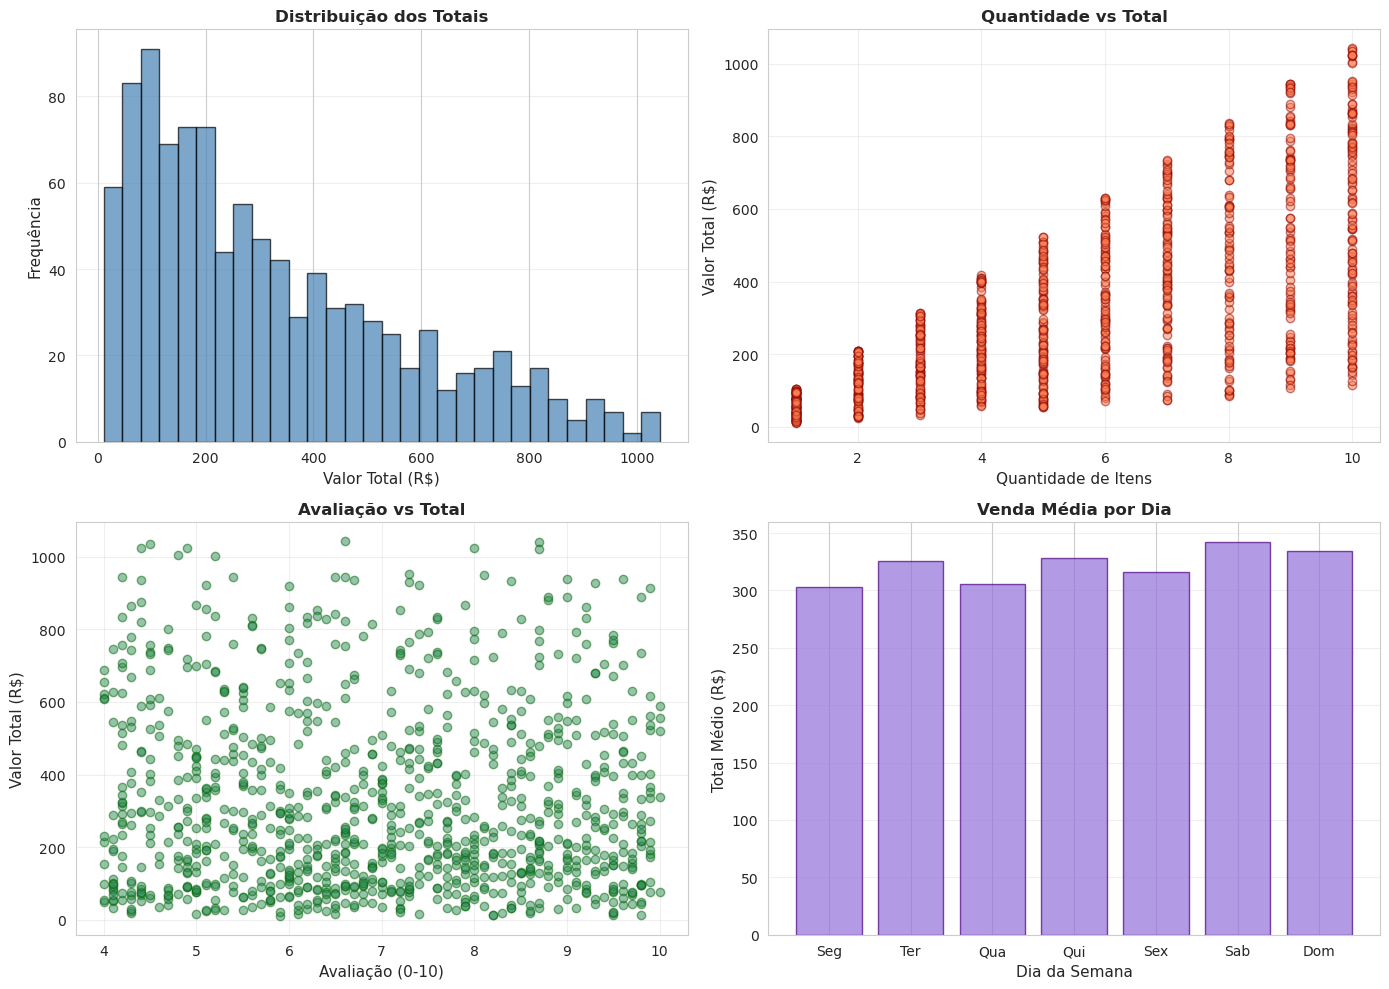

In [49]:
# Configurar estilo
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 10)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Gráfico 1: Como os valores totais se distribuem
axes[0, 0].hist(df['Total'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_xlabel('Valor Total (R$)', fontsize=11)
axes[0, 0].set_ylabel('Frequência', fontsize=11)
axes[0, 0].set_title('Distribuição dos Totais', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Gráfico 2: Total vs Quantidade (forte relação, faz sentido!)
axes[0, 1].scatter(df['Quantity'], df['Total'], alpha=0.5, color='coral', edgecolors='darkred')
axes[0, 1].set_xlabel('Quantidade de Itens', fontsize=11)
axes[0, 1].set_ylabel('Valor Total (R$)', fontsize=11)
axes[0, 1].set_title('Quantidade vs Total', fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Gráfico 3: Total vs Rating (nota que não tem relação forte)
axes[1, 0].scatter(df['Rating'], df['Total'], alpha=0.5, color='seagreen', edgecolors='darkgreen')
axes[1, 0].set_xlabel('Avaliação (0-10)', fontsize=11)
axes[1, 0].set_ylabel('Valor Total (R$)', fontsize=11)
axes[1, 0].set_title('Avaliação vs Total', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)

# Gráfico 4: Qual dia da semana vende mais
daily_avg = df.groupby('DayOfWeek')['Total'].mean()
days_labels = ['Seg', 'Ter', 'Qua', 'Qui', 'Sex', 'Sab', 'Dom']
axes[1, 1].bar(range(len(daily_avg)), daily_avg.values, color='mediumpurple', edgecolor='indigo', alpha=0.7)
axes[1, 1].set_xticks(range(len(daily_avg)))
axes[1, 1].set_xticklabels(days_labels)
axes[1, 1].set_xlabel('Dia da Semana', fontsize=11)
axes[1, 1].set_ylabel('Total Médio (R$)', fontsize=11)
axes[1, 1].set_title('Venda Média por Dia', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [50]:
print("💡 Insights dos gráficos:")
print("  1. Valores totais têm uma distribuição bem normal")
print("  2. Quantidade tem relação FORTE com o total (lógico!)")
print("  3. Rating não tá muito relacionado com valor total")
print("  4. Finais de semana vendem mais que segunda-feira")

💡 Insights dos gráficos:
  1. Valores totais têm uma distribuição bem normal
  2. Quantidade tem relação FORTE com o total (lógico!)
  3. Rating não tá muito relacionado com valor total
  4. Finais de semana vendem mais que segunda-feira


## 7. Preparando pra treinar o modelo

In [51]:
# ANALISANDO COLUNAS DISPONÍVEIS
print("ANALISANDO COLUNAS DISPONÍVEIS")
print("="*60)
print(f"Total de colunas no dataset: {len(df.columns)}")
print(f"\nColunas atuais:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

print("\n" + "="*60)
print("PREPARAÇÃO DOS DADOS")
print("="*60)

# Descartar as colunas que não vamos usar (com segurança)
# Usando errors='ignore' pra não quebrar se não achar a coluna
colunas_a_descartar = [
    'Invoice ID', 'Branch', 'City', 'Customer type', 'Gender', 
    'Product line', 'Date', 'Payment',
    'Tax 5%', 'cogs', 'gross margin percentage', 'gross income',
    'Time']

# Descartar com segurança
X = df.drop(columns=colunas_a_descartar, errors='ignore')

# Remover a coluna alvo (Total) também
X = X.drop(columns=['Total'], errors='ignore')

# Target é sempre o Total
y = df['Total']

print(f"\n✓ Features preparadas!")
print(f"  X shape: {X.shape[0]} amostras × {X.shape[1]} variáveis")
print(f"  y shape: {y.shape[0]} amostras")

print(f"\nVariáveis que vão ser usadas no modelo:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i}. {col}")

print(f"\n✅ Pronto pra treinar!")

ANALISANDO COLUNAS DISPONÍVEIS
Total de colunas no dataset: 34

Colunas atuais:
  1. Invoice ID
  2. Branch
  3. City
  4. Customer type
  5. Gender
  6. Product line
  7. Unit price
  8. Quantity
  9. Tax 5%
  10. Total
  11. Date
  12. Time
  13. Payment
  14. cogs
  15. gross margin percentage
  16. gross income
  17. Rating
  18. Month
  19. DayOfWeek
  20. Quarter
  21. Gender_encoded
  22. Customer_type_encoded
  23. ProductLine_Electronic accessories
  24. ProductLine_Fashion accessories
  25. ProductLine_Food and beverages
  26. ProductLine_Health and beauty
  27. ProductLine_Home and lifestyle
  28. ProductLine_Sports and travel
  29. Payment_Cash
  30. Payment_Credit card
  31. Payment_Ewallet
  32. Branch_A
  33. Branch_B
  34. Branch_C

PREPARAÇÃO DOS DADOS

✓ Features preparadas!
  X shape: 1000 amostras × 20 variáveis
  y shape: 1000 amostras

Variáveis que vão ser usadas no modelo:
  1. Unit price
  2. Quantity
  3. Rating
  4. Month
  5. DayOfWeek
  6. Quarter
  7. Gend

In [52]:
# Dividir em treino e teste (80% treino, 20% teste)
# Treino: o modelo aprende com isso
# Teste: a gente valida com dados que o modelo nunca viu
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("DIVISÃO TREINO/TESTE")
print("="*60)
print(f"✓ Dados divididos!")
print(f"  Treino: {X_train.shape[0]} amostras ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Teste:  {X_test.shape[0]} amostras ({X_test.shape[0]/len(X)*100:.1f}%)")

DIVISÃO TREINO/TESTE
✓ Dados divididos!
  Treino: 800 amostras (80.0%)
  Teste:  200 amostras (20.0%)


## 8. Treinando os modelos

Vou treinar dois modelos diferentes e depois ver qual um é melhor:
1. **Random Forest** — mais sofisticado, captura padrões complexos
2. **Regressão Linear** — mais simples, só tira uma reta que melhor encaixa

In [53]:
# Modelo 1: Random Forest
print("TREINANDO RANDOM FOREST")
print("="*60)

modelo_rf = RandomForestRegressor(
    n_estimators=100,      # 100 árvores
    max_depth=15,          # profundidade máxima
    min_samples_split=5,   # mínimo de amostras pra dividir
    random_state=42,
    n_jobs=-1              # usa todos os processadores
)

modelo_rf.fit(X_train, y_train)
print("✓ Random Forest pronto!")

# Fazer previsões
y_pred_rf_train = modelo_rf.predict(X_train)
y_pred_rf_test = modelo_rf.predict(X_test)
print("✓ Previsões feitas")

TREINANDO RANDOM FOREST
✓ Random Forest pronto!
✓ Previsões feitas


In [54]:
# Modelo 2: Regressão Linear
print("\nTREINANDO REGRESSÃO LINEAR")
print("="*60)

modelo_linear = LinearRegression()
modelo_linear.fit(X_train, y_train)
print("✓ Regressão Linear pronta!")

# Fazer previsões
y_pred_linear_train = modelo_linear.predict(X_train)
y_pred_linear_test = modelo_linear.predict(X_test)
print("✓ Previsões feitas")


TREINANDO REGRESSÃO LINEAR
✓ Regressão Linear pronta!
✓ Previsões feitas


## 9. Validando os resultados

Agora a gente vê qual modelo se saiu melhor. Vou usar 3 métricas:
- **R²**: quanto do padrão o modelo conseguiu capturar (0 a 1, quanto maior melhor)
- **MAE**: erro médio em reais (quanto menor melhor)
- **RMSE**: tipo MAE mas penaliza erros maiores mais ainda (quanto menor melhor)

In [55]:
# Avaliar Random Forest
print("\nAVALIAÇÃO - RANDOM FOREST")
print("="*60)

r2_rf_train = r2_score(y_train, y_pred_rf_train)
r2_rf_test = r2_score(y_test, y_pred_rf_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf_test)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))

print(f"\n📊 Resultados no conjunto TESTE:")
print(f"  R²:    {r2_rf_test:.4f}")
print(f"  MAE:   R$ {mae_rf:.2f}")
print(f"  RMSE:  R$ {rmse_rf:.2f}")

print(f"\n📊 Resultados no conjunto TREINO:")
print(f"  R²:    {r2_rf_train:.4f}")

print(f"\n💡 O que isso significa:")
print(f"  • Explica {r2_rf_test*100:.1f}% da variação nos dados")
print(f"  • Em média, erra por R$ {mae_rf:.2f}")


AVALIAÇÃO - RANDOM FOREST

📊 Resultados no conjunto TESTE:
  R²:    0.9982
  MAE:   R$ 7.28
  RMSE:  R$ 10.83

📊 Resultados no conjunto TREINO:
  R²:    0.9995

💡 O que isso significa:
  • Explica 99.8% da variação nos dados
  • Em média, erra por R$ 7.28


In [56]:
# Avaliar Regressão Linear
print("\nAVALIAÇÃO - REGRESSÃO LINEAR")
print("="*60)

r2_linear_train = r2_score(y_train, y_pred_linear_train)
r2_linear_test = r2_score(y_test, y_pred_linear_test)
mae_linear = mean_absolute_error(y_test, y_pred_linear_test)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear_test))

print(f"\n📊 Resultados no conjunto TESTE:")
print(f"  R²:    {r2_linear_test:.4f}")
print(f"  MAE:   R$ {mae_linear:.2f}")
print(f"  RMSE:  R$ {rmse_linear:.2f}")

print(f"\n📊 Resultados no conjunto TREINO:")
print(f"  R²:    {r2_linear_train:.4f}")

print(f"\n💡 O que isso significa:")
print(f"  • Explica {r2_linear_test*100:.1f}% da variação nos dados")
print(f"  • Em média, erra por R$ {mae_linear:.2f}")


AVALIAÇÃO - REGRESSÃO LINEAR

📊 Resultados no conjunto TESTE:
  R²:    0.9025
  MAE:   R$ 59.21
  RMSE:  R$ 79.64

📊 Resultados no conjunto TREINO:
  R²:    0.8876

💡 O que isso significa:
  • Explica 90.3% da variação nos dados
  • Em média, erra por R$ 59.21


In [57]:
# Comparação lado a lado
print("\nCOMPARAÇÃO DOS DOIS")
print("="*60)

comparacao = pd.DataFrame({
    'Métrica': ['R² (Teste)', 'MAE (Teste)', 'RMSE (Teste)', 'R² (Treino)'],
    'Random Forest': [
        f"{r2_rf_test:.4f}",
        f"R$ {mae_rf:.2f}",
        f"R$ {rmse_rf:.2f}",
        f"{r2_rf_train:.4f}"
    ],
    'Linear': [
        f"{r2_linear_test:.4f}",
        f"R$ {mae_linear:.2f}",
        f"R$ {rmse_linear:.2f}",
        f"{r2_linear_train:.4f}"
    ]
})

print("\n")
print(comparacao.to_string(index=False))

melhor_modelo = "Random Forest" if r2_rf_test > r2_linear_test else "Linear"
print(f"\n✅ MELHOR MODELO: {melhor_modelo}")


COMPARAÇÃO DOS DOIS


     Métrica Random Forest   Linear
  R² (Teste)        0.9982   0.9025
 MAE (Teste)       R$ 7.28 R$ 59.21
RMSE (Teste)      R$ 10.83 R$ 79.64
 R² (Treino)        0.9995   0.8876

✅ MELHOR MODELO: Random Forest


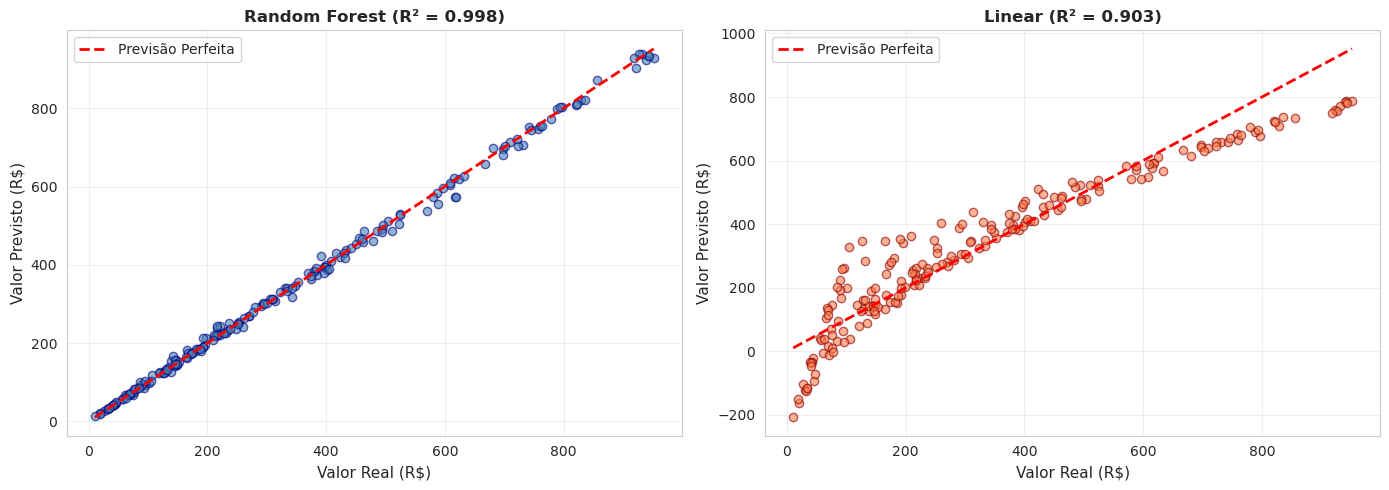


💡 Como ler os gráficos:
  • Pontos perto da linha vermelha = acertou!
  • Pontos espalhados = errou mais
  • Random Forest geralmente concentra mais perto da reta


In [58]:
# Visualizar como os modelos acertam/erram
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Random Forest
axes[0].scatter(y_test, y_pred_rf_test, alpha=0.6, color='steelblue', edgecolors='navy')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Previsão Perfeita')
axes[0].set_xlabel('Valor Real (R$)', fontsize=11)
axes[0].set_ylabel('Valor Previsto (R$)', fontsize=11)
axes[0].set_title(f'Random Forest (R² = {r2_rf_test:.3f})', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Linear
axes[1].scatter(y_test, y_pred_linear_test, alpha=0.6, color='coral', edgecolors='darkred')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
             'r--', lw=2, label='Previsão Perfeita')
axes[1].set_xlabel('Valor Real (R$)', fontsize=11)
axes[1].set_ylabel('Valor Previsto (R$)', fontsize=11)
axes[1].set_title(f'Linear (R² = {r2_linear_test:.3f})', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Como ler os gráficos:")
print("  • Pontos perto da linha vermelha = acertou!")
print("  • Pontos espalhados = errou mais")
print("  • Random Forest geralmente concentra mais perto da reta")

In [59]:
# Mostrar alguns exemplos de previsão
print("\nEXEMPLOS DE PREVISÕES (primeiras 10):")
print("="*60)

exemplos = pd.DataFrame({
    'Valor Real': y_test.head(10).values,
    'Random Forest': np.round(y_pred_rf_test[:10], 2),
    'Erro RF': np.abs(np.round(y_test.head(10).values - y_pred_rf_test[:10], 2)),
    'Linear': np.round(y_pred_linear_test[:10], 2),
    'Erro Linear': np.abs(np.round(y_test.head(10).values - y_pred_linear_test[:10], 2))
})

print(exemplos.to_string(index=False))


EXEMPLOS DE PREVISÕES (primeiras 10):
 Valor Real  Random Forest  Erro RF  Linear  Erro Linear
   523.9710         530.87     6.90  519.56         4.41
   616.9800         573.13    43.85  591.70        25.28
   408.7335         409.87     1.14  411.33         2.59
   135.3555         140.10     4.75   88.90        46.45
    45.9270          47.90     1.97  -93.84       139.76
   618.9750         574.48    44.49  591.99        26.99
   127.8270         125.39     2.44  134.50         6.67
   731.6925         705.63    26.06  657.44        74.25
   450.1035         452.53     2.42  485.00        34.90
   138.1275         125.61    12.52  126.35        11.78


## 10. Salvando o modelo pra usar depois

In [60]:
# Determinar qual é o melhor e salvar
if r2_rf_test > r2_linear_test:
    modelo_final = modelo_rf
    nome_modelo = "Random Forest"
else:
    modelo_final = modelo_linear
    nome_modelo = "Linear"

# ✅ FIX: Converter colunas pra lista (não pandas.Index)
colunas_lista = list(X.columns)

# Salvar os arquivos
with open('dados/modelo_venda.pkl', 'wb') as f:
    pickle.dump(modelo_final, f)

with open('dados/colunas_modelo.pkl', 'wb') as f:
    pickle.dump(colunas_lista, f)

print(f"✓ Modelo salvo!")
print(f"\n📁 Arquivos criados:")
print(f"  1. modelo_venda.pkl ({nome_modelo})")
print(f"  2. colunas_modelo.pkl ({len(colunas_lista)} features)")

print(f"\n💡 Estrutura das features:")
product_cols = [c for c in colunas_lista if c.startswith('ProductLine')]
payment_cols = [c for c in colunas_lista if c.startswith('Payment')]
branch_cols = [c for c in colunas_lista if c.startswith('Branch')]
print(f"  • Numéricas: Unit price, Quantity, Rating, Month, DayOfWeek, Quarter")
print(f"  • Codificadas: Gender_encoded, Customer_type_encoded")
print(f"  • One-hot: {len(product_cols)} produtos, {len(payment_cols)} pagamentos, {len(branch_cols)} filiais")

✓ Modelo salvo!

📁 Arquivos criados:
  1. modelo_venda.pkl (Random Forest)
  2. colunas_modelo.pkl (20 features)

💡 Estrutura das features:
  • Numéricas: Unit price, Quantity, Rating, Month, DayOfWeek, Quarter
  • Codificadas: Gender_encoded, Customer_type_encoded
  • One-hot: 6 produtos, 3 pagamentos, 3 filiais
